     y         x1         x2         x3         x4        x5         x6  \
0  0.1   98.37983   98.47062   98.59725   98.83019   99.2159   99.76074   
1  0.1  100.66020  100.69360  100.90240  101.30790  101.8773  102.53660   
2  0.1   99.90228  100.11980  100.40350  100.78680  101.2848  101.88110   
3  0.0  103.23370  102.93490  102.81470  102.89630  103.1540  103.52200   
4  0.0  103.13950  103.02040  103.01270  103.19860  103.6126  104.22820   

         x7        x8        x9  ...     x7458     x7459     x7460     x7461  \
0  100.4251  101.1340  101.7940  ...  91.86108  91.86584  91.87341  91.88235   
1  103.1914  103.7471  104.1258  ...  91.27203  91.28791  91.30771  91.33030   
2  102.5213  103.1199  103.5759  ...  91.84032  91.84180  91.84767  91.85847   
3  103.9131  104.2405  104.4365  ...  94.42875  94.44038  94.45107  94.46045   
4  104.9608  105.6926  106.3046  ...  97.92164  97.94044  97.95722  97.97008   

      x7462     x7463     x7464     x7465     x7466     x7467  
0  9

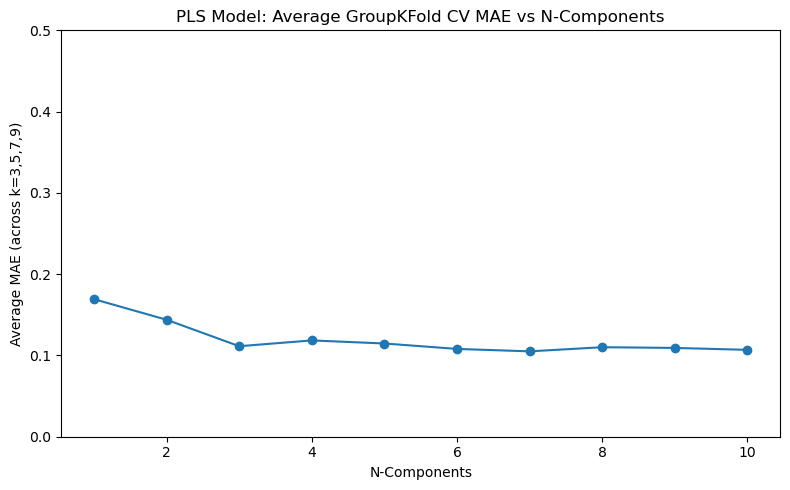

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/'

files = [file for file in os.listdir(root_directory) if file.lower().endswith('.csv')]
files.sort()

files = files[:33]

y_values = [0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
           0.3, 0.3, 0.3, 0.2, 0.2, 0.2]

if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []

for file, y_value in zip(files, y_values):
    file_path = os.path.join(root_directory, file)
    data = pd.read_csv(file_path, header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_value)
    rows.append(row)
    
min_len = min(len(r) for r in rows)
trimmed_rows = [r[:min_len] for r in rows]


columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
final_df = pd.DataFrame(trimmed_rows, columns=columns)

print(final_df.head())
y = final_df.iloc[:, 0]
X = final_df.iloc[:, 1:]
print(X.head())
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)
print(y_train)

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error 
from sklearn.model_selection import GroupKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

groups = [i // 3 for i in range(len(files))] 
max_components = 10

final_scores = [] 

for n_comp in range(1, max_components + 1):
    mae_for_k = [] 
    
    for k in [3, 5, 7, 9]:
        gkf = GroupKFold(n_splits=k)
        fold_maes = []
        
        for train_index, val_index in gkf.split(X, y, groups):
            X_train, X_val = X.iloc[train_index], X.iloc[val_index]
            y_train, y_val = y.iloc[train_index], y.iloc[val_index]
            
            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train, y_train)
            y_pred = pls.predict(X_val)
            mae = mean_absolute_error(y_val, y_pred)
            fold_maes.append(mae)
        
        mean_mae_k = np.mean(fold_maes)
        print(f"n_components={n_comp}, k={k}, Mean MAE: {mean_mae_k:.4f}")
        mae_for_k.append(mean_mae_k)
    
    overall_avg_mae = np.mean(mae_for_k)
    print(f"n_components={n_comp}, Overall Avg MAE across k=3,5,7,9: {overall_avg_mae:.4f}")
    final_scores.append((n_comp, overall_avg_mae))
final_df = pd.DataFrame(final_scores, columns=['n_components', 'avg_mae'])

plt.figure(figsize=(8,5))
plt.plot(final_df['n_components'], final_df['avg_mae'], marker='o')
plt.ylim(0, 0.5)
plt.xlabel('N-Components')
plt.ylabel('Average MAE (across k=3,5,7,9)')
plt.title('PLS Model: Average GroupKFold CV MAE vs N-Components')
plt.tight_layout()
plt.show()

Found 33 calibration files
Loaded 33 spectra with 7467 features
Loaded 4 solvent spectra
Augmented dataset size: 561 samples
n_components=1, k=3, MAE=0.2613
n_components=1, k=5, MAE=0.2596
n_components=1, k=7, MAE=0.2618
n_components=1, k=9, MAE=0.2614
n_components=1, AVG MAE: 0.2610

n_components=2, k=3, MAE=0.1428
n_components=2, k=5, MAE=0.1367
n_components=2, k=7, MAE=0.1488
n_components=2, k=9, MAE=0.1439
n_components=2, AVG MAE: 0.1430

n_components=3, k=3, MAE=0.1415
n_components=3, k=5, MAE=0.1352
n_components=3, k=7, MAE=0.1465
n_components=3, k=9, MAE=0.1417
n_components=3, AVG MAE: 0.1412

n_components=4, k=3, MAE=0.1349
n_components=4, k=5, MAE=0.1303
n_components=4, k=7, MAE=0.1371
n_components=4, k=9, MAE=0.1355
n_components=4, AVG MAE: 0.1345

n_components=5, k=3, MAE=0.1252
n_components=5, k=5, MAE=0.1109
n_components=5, k=7, MAE=0.1298
n_components=5, k=9, MAE=0.1264
n_components=5, AVG MAE: 0.1231

n_components=6, k=3, MAE=0.0877
n_components=6, k=5, MAE=0.0792
n_comp

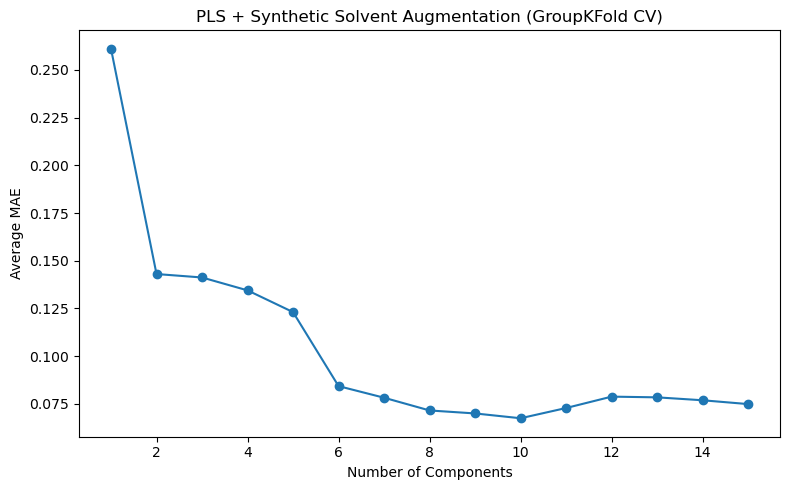

In [4]:
import os
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt

# PATHS (FIX THESE IF NEEDED)
root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'

# CHECK PATHS
if not os.path.exists(root_calib):
    raise ValueError(f"Calibration folder not found: {root_calib}")

if not os.path.exists(solvent_dir):
    raise ValueError(f"Solvent folder not found: {solvent_dir}")

# LOAD FILES
calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])

if len(calib_files) == 0:
    raise ValueError("No CSV files found in calibration directory!")

calib_files = calib_files[:33]

print(f"Found {len(calib_files)} calibration files")

y_values = [
    0.1,0.1,0.1,0,0,0,1,1,1,0.9,0.9,0.9,
    0.8,0.8,0.8,0.7,0.7,0.7,0.6,0.6,0.6,
    0.5,0.5,0.5,0.4,0.4,0.4,0.3,0.3,0.3,
    0.2,0.2,0.2
]

if len(calib_files) != len(y_values):
    raise ValueError("Mismatch between files and y_values!")

# LOAD SPECTRA
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

rows = []

for file, y_val in zip(calib_files, y_values):
    path = os.path.join(root_calib, file)
    
    try:
        spec = load_spectrum(path)
        if len(spec) == 0:
            print(f"Skipping empty file: {file}")
            continue
        
        row = np.insert(spec, 0, y_val)
        rows.append(row)
        
    except Exception as e:
        print(f"Error loading {file}: {e}")


if len(rows) == 0:
    raise ValueError("No valid spectra loaded. Check your CSV format or paths.")

# ALIGN LENGTHS
min_len = min(len(r) for r in rows)
rows = [r[:min_len] for r in rows]

columns = ['y'] + [f'x{i}' for i in range(min_len-1)]
df = pd.DataFrame(rows, columns=columns)

y_calib = df['y'].values
X_calib = df.drop('y', axis=1).values

n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} spectra with {n_features} features")

# LOAD SOLVENTS
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = {}

for file in solvent_files:
    path = os.path.join(solvent_dir, file)
    
    if not os.path.exists(path):
        print(f"WARNING: Missing solvent file: {file}")
        continue
    
    spec = load_spectrum(path)
    
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0,1,n_features),
                         np.linspace(0,1,len(spec)), spec)
    
    solvents[file] = spec

if len(solvents) == 0:
    raise ValueError("No solvent spectra loaded!")

print(f"Loaded {len(solvents)} solvent spectra")


# SYNTHETIC AUGMENTATION
alphas = np.arange(0.1, 0.5, 0.1)

X_all = [X_calib]
y_all = [y_calib]
groups_all = [np.arange(len(y_calib))]

def synthesize(x, solvent, alpha):
    return x + alpha * solvent 

for solvent in solvents.values():
    for alpha in alphas:
        X_syn = np.array([synthesize(x, solvent, alpha) for x in X_calib])
        
        X_all.append(X_syn)
        y_all.append(y_calib)
        groups_all.append(np.arange(len(y_calib)))  # preserve grouping

X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)
groups = np.concatenate(groups_all)

print(f"Augmented dataset size: {len(X_all)} samples")


# GROUP K-FOLD CV
max_components = 15
k_values = [3, 5, 7, 9]

results = []

for n_comp in range(1, max_components + 1):
    mae_across_k = []
    
    for k in k_values:
        gkf = GroupKFold(n_splits=k)
        fold_maes = []
        
        for train_idx, val_idx in gkf.split(X_all, y_all, groups):
            X_train, X_val = X_all[train_idx], X_all[val_idx]
            y_train, y_val = y_all[train_idx], y_all[val_idx]
            
            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train, y_train)
            
            y_pred = pls.predict(X_val)
            mae = mean_absolute_error(y_val, y_pred)
            fold_maes.append(mae)
        
        mean_mae_k = np.mean(fold_maes)
        print(f"n_components={n_comp}, k={k}, MAE={mean_mae_k:.4f}")
        mae_across_k.append(mean_mae_k)
    
    avg_mae = np.mean(mae_across_k)
    print(f"n_components={n_comp}, AVG MAE: {avg_mae:.4f}\n")
    
    results.append((n_comp, avg_mae))

# PLOTs
results_df = pd.DataFrame(results, columns=['n_components', 'avg_mae'])

plt.figure(figsize=(8,5))
plt.plot(results_df['n_components'], results_df['avg_mae'], marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Average MAE')
plt.title('PLS + Synthetic Solvent Augmentation (GroupKFold CV)')
plt.tight_layout()
plt.show()

X shape: (33, 7467)
Y shape: (33, 2)

========== Components = 1 ==========
k=3  Mean MAE = 0.1806
k=5  Mean MAE = 0.1723
k=7  Mean MAE = 0.1479
k=9  Mean MAE = 0.1760
Overall Average MAE = 0.1692

========== Components = 2 ==========
k=3  Mean MAE = 0.1348
k=5  Mean MAE = 0.1516
k=7  Mean MAE = 0.1451
k=9  Mean MAE = 0.1440
Overall Average MAE = 0.1439

========== Components = 3 ==========
k=3  Mean MAE = 0.1060
k=5  Mean MAE = 0.1096
k=7  Mean MAE = 0.1127
k=9  Mean MAE = 0.1172
Overall Average MAE = 0.1114

========== Components = 4 ==========
k=3  Mean MAE = 0.1074
k=5  Mean MAE = 0.1239
k=7  Mean MAE = 0.1242
k=9  Mean MAE = 0.1184
Overall Average MAE = 0.1185

========== Components = 5 ==========
k=3  Mean MAE = 0.1038
k=5  Mean MAE = 0.1229
k=7  Mean MAE = 0.1122
k=9  Mean MAE = 0.1199
Overall Average MAE = 0.1147

========== Components = 6 ==========
k=3  Mean MAE = 0.1107
k=5  Mean MAE = 0.1114
k=7  Mean MAE = 0.0978
k=9  Mean MAE = 0.1123
Overall Average MAE = 0.1080

========

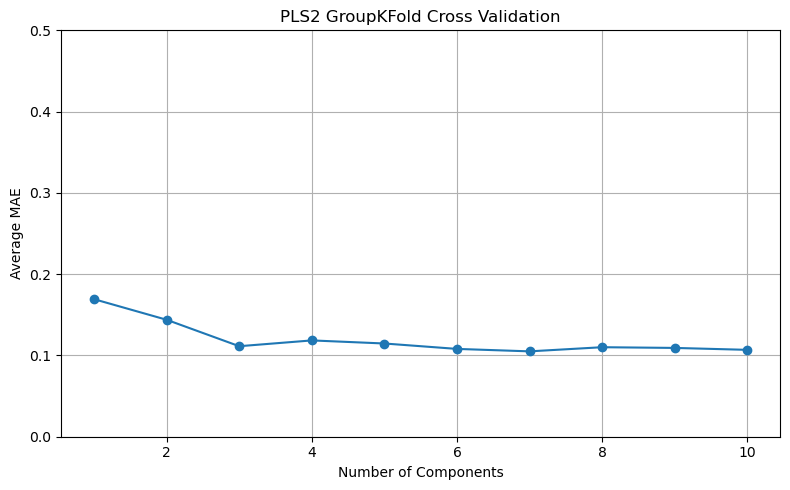

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error

# ==========================
# Load spectra
# ==========================

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/'

files = [file for file in os.listdir(root_directory) if file.lower().endswith('.csv')]
files.sort()

files = files[:33]

y_values = [
    0.1, 0.1, 0.1,
    0, 0, 0,
    1, 1, 1,
    0.9, 0.9, 0.9,
    0.8, 0.8, 0.8,
    0.7, 0.7, 0.7,
    0.6, 0.6, 0.6,
    0.5, 0.5, 0.5,
    0.4, 0.4, 0.4,
    0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []

for file, y_value in zip(files, y_values):

    file_path = os.path.join(root_directory, file)

    data = pd.read_csv(
        file_path,
        header=None,
        skiprows=1
    )

    spectrum = data.iloc[:,1].values

    row = np.insert(spectrum, 0, y_value)

    rows.append(row)

min_len = min(len(r) for r in rows)

trimmed_rows = [r[:min_len] for r in rows]

columns = ['AgOAc'] + [f'x{i+1}' for i in range(min_len-1)]

final_df = pd.DataFrame(trimmed_rows, columns=columns)

# ==========================
# Create PLS2 outputs
# ==========================

Y = pd.DataFrame({
    "AgOAc": final_df["AgOAc"],
    "Pyridone": 1 - final_df["AgOAc"]
})

X = final_df.iloc[:,1:]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# ==========================
# Group labels
# ==========================

groups = [i // 3 for i in range(len(files))]

max_components = 10

final_scores = []

# ==========================
# GroupKFold Cross Validation
# ==========================

for n_comp in range(1, max_components + 1):

    mae_for_k = []

    print(f"\n========== Components = {n_comp} ==========")

    for k in [3,5,7,9]:

        gkf = GroupKFold(n_splits=k)

        fold_maes = []

        for train_index, val_index in gkf.split(X, Y, groups):

            X_train = X.iloc[train_index]
            X_val = X.iloc[val_index]

            Y_train = Y.iloc[train_index]
            Y_val = Y.iloc[val_index]

            pls = PLSRegression(n_components=n_comp)

            pls.fit(X_train, Y_train)

            Y_pred = pls.predict(X_val)

            # Average MAE over both outputs
            mae = mean_absolute_error(
                Y_val,
                Y_pred
            )

            fold_maes.append(mae)

        mean_mae_k = np.mean(fold_maes)

        print(f"k={k}  Mean MAE = {mean_mae_k:.4f}")

        mae_for_k.append(mean_mae_k)

    overall_avg = np.mean(mae_for_k)

    final_scores.append((n_comp, overall_avg))

    print(f"Overall Average MAE = {overall_avg:.4f}")

# ==========================
# Results
# ==========================

results = pd.DataFrame(
    final_scores,
    columns=["n_components", "avg_mae"]
)

print(results)

# ==========================
# Plot
# ==========================

plt.figure(figsize=(8,5))

plt.plot(
    results["n_components"],
    results["avg_mae"],
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Average MAE")
plt.title("PLS2 GroupKFold Cross Validation")

plt.ylim(0,0.5)

plt.grid(True)

plt.tight_layout()

plt.show()